In [4]:
import tensorflow as tf
from keras import layers,datasets,Sequential
import matplotlib.pyplot as plt
from PIL import Image
import numpy as np

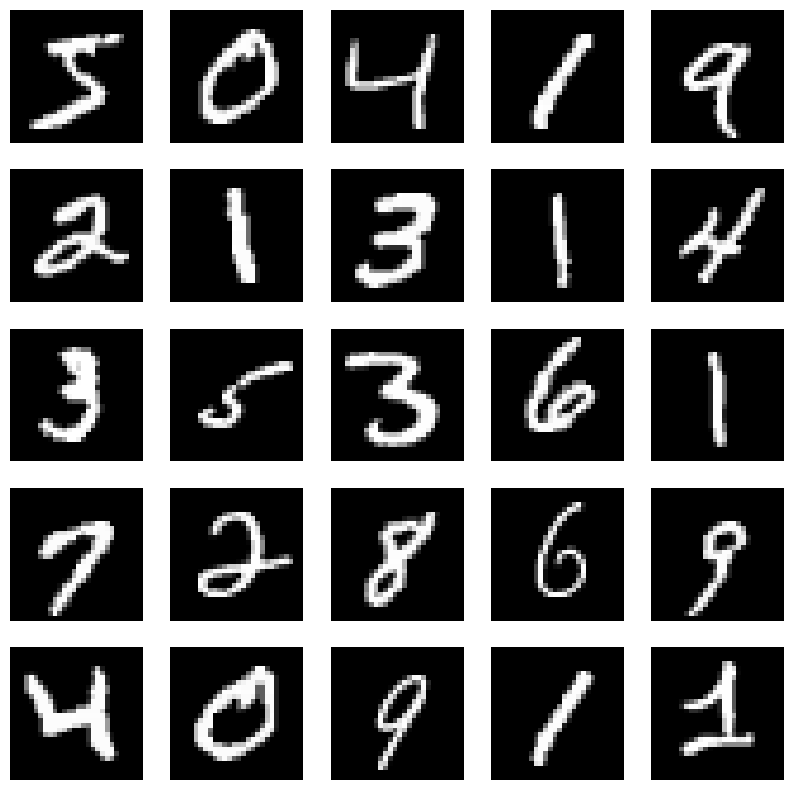

In [5]:
(x_train,y_train),(x_test,y_test)=datasets.mnist.load_data()
plt.figure(figsize=(10,10))
for i in range(25):
    plt.subplot(5,5,i+1)
    plt.imshow(x_train[i],cmap='gray')
    plt.axis('off')
plt.show()

In [6]:
x_train=x_train.reshape(-1,28,28,1).astype('float32')/255.0
x_test=x_test.reshape(-1,28,28,1).astype('float32')/255.0
model=Sequential(
    [
        layers.Conv2D(32,kernel_size=(3,3),activation='relu',input_shape=(28,28,1)),
        layers.MaxPooling2D(pool_size=(2,2)),
        layers.Conv2D(64,kernel_size=(3,3),activation='relu'),
        layers.MaxPooling2D(pool_size=(2,2)),
        layers.Flatten(),
        layers.Dense(128,activation='softmax'),
    ]
)
model.compile(optimizer='adam',loss='sparse_categorical_crossentropy',metrics=['accuracy'])
history=model.fit(x_train,y_train,epochs=10,validation_data=(x_test,y_test))

C:\Users\Flipper\miniconda3\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 17s 8ms/step - accuracy: 0.9425 - loss: 0.1902 - val_accuracy: 0.9779 - val_loss: 0.0684
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 15s 8ms/step - accuracy: 0.9813 - loss: 0.0610 - val_accuracy: 0.9832 - val_loss: 0.0502
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 15s 8ms/step - accuracy: 0.9861 - loss: 0.0460 - val_accuracy: 0.9874 - val_loss: 0.0360
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 17s 9ms/step - accuracy: 0.9892 - loss: 0.0351 - val_accuracy: 0.9895 - val_loss: 0.0309
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 16s 9ms/step - accuracy: 0.9908 - loss: 0.0281 - val_accuracy: 0.9888 - val_loss: 0.0326
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 16s 8ms/step - accuracy: 0.9932 - loss: 0.0214 - val_accuracy: 0.9895 - val_loss: 0.0336
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 24s 13ms/step - accuracy: 0.9938 - loss: 0.0180 - val_accuracy: 0.9902 - val_loss: 0.0306
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 26s 14ms/step - accuracy: 0.9952 - loss:

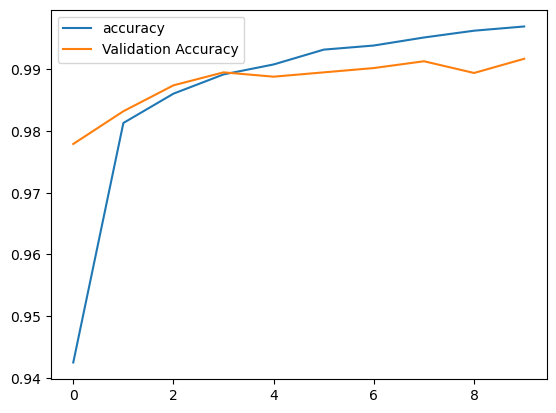

In [7]:
plt.plot(history.history['accuracy'], label='accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.legend()
plt.show()

In [8]:
def predict_image(image_path):
    img=Image.open(image_path).resize((28,28)).convert('L')
    img_array=np.array(img)
    plt.imshow(img_array)
    plt.show()
    res=model.predict(img_array.reshape(1, 28, 28, 1)/255.0)[0]
    print(np.argmax(res))

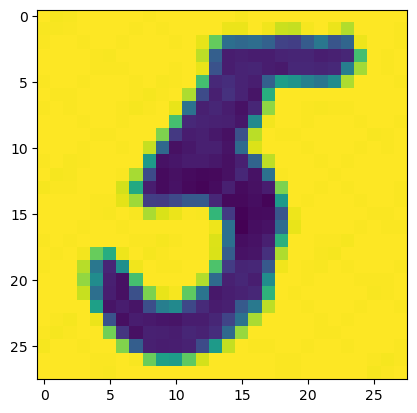

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step
5


In [9]:
predict_image("five2.jpg")